In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import warnings
warnings.filterwarnings('ignore')
from sklearn.preprocessing import LabelEncoder
df = pd.read_csv('../../backend/DATA/dataset_with_skills.csv')

print(df.columns.tolist())
# df = pd.read_csv("../../backend/DATA/jobs_dataset.csv")
print(f'Shape : {df.shape}')
df.head()

['index', 'Job Title', 'Salary Estimate', 'Job Description', 'Rating', 'Company Name', 'Location', 'Headquarters', 'Size', 'Founded', 'Type of ownership', 'Industry', 'Sector', 'Revenue', 'Competitors', 'extracted_skills']
Shape : (100, 16)


,index,Job Title,Salary Estimate,Job Description,Rating,Company Name,Location,Headquarters,Size,Founded,Type of ownership,Industry,Sector,Revenue,Competitors,extracted_skills
0,0,Sr Data Scientist,$137K-$171K (Glassdoor est.),Description\n\nThe Senior Data Scientist is re...,3.1,Healthfirst\n3.1,"New York, NY","New York, NY",1001 to 5000 employees,1993,Nonprofit Organization,Insurance Carriers,Insurance,Unknown / Non-Applicable,"EmblemHealth, UnitedHealth Group, Aetna","data, performance metrics, acquisition, quanti..."
1,1,Data Scientist,$137K-$171K (Glassdoor est.),"Secure our Nation, Ignite your Future\n\nJoin ...",4.2,ManTech\n4.2,"Chantilly, VA","Herndon, VA",5001 to 10000 employees,1968,Company - Public,Research & Development,Business Services,$1 to $2 billion (USD),-1,"data sets, data holdings, infrastructure, trou..."
2,2,Data Scientist,$137K-$171K (Glassdoor est.),Overview\n\n\nAnalysis Group is one of the lar...,3.8,Analysis Group\n3.8,"Boston, MA","Boston, MA",1001 to 5000 employees,1981,Private Practice / Firm,Consulting,Business Services,$100 to $500 million (USD),-1,"life sciences, analytical services, finance, b..."
3,3,Data Scientist,$137K-$171K (Glassdoor est.),JOB DESCRIPTION:\n\nDo you have a passion for ...,3.5,INFICON\n3.5,"Newton, MA","Bad Ragaz, Switzerland",501 to 1000 employees,2000,Company - Public,Electrical & Electronic Manufacturing,Manufacturing,$100 to $500 million (USD),"MKS Instruments, Pfeiffer Vacuum, Agilent Tech...","data, developing, time series data, Machine Le..."
4,4,Data Scientist,$137K-$171K (Glassdoor est.),Data Scientist\nAffinity Solutions / Marketing...,2.9,Affinity Solutions\n2.9,"New York, NY","New York, NY",51 to 200 employees,1998,Company - Private,Advertising & Marketing,Business Services,Unknown / Non-Applicable,"Commerce Signals, Cardlytics, Yodlee","data, research, measurement methodology, techn..."


In [19]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 16 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   index              100 non-null    int64  
 1   Job Title          100 non-null    str    
 2   Salary Estimate    100 non-null    str    
 3   Job Description    100 non-null    str    
 4   Rating             100 non-null    float64
 5   Company Name       100 non-null    str    
 6   Location           100 non-null    str    
 7   Headquarters       100 non-null    str    
 8   Size               100 non-null    str    
 9   Founded            100 non-null    int64  
 10  Type of ownership  100 non-null    str    
 11  Industry           100 non-null    str    
 12  Sector             100 non-null    str    
 13  Revenue            100 non-null    str    
 14  Competitors        100 non-null    str    
 15  extracted_skills   100 non-null    str    
dtypes: float64(1), int64(2), str(13)
memor

In [20]:
# Valeurs manquantes
missing = df.isnull().sum().sort_values(ascending=False)
missing_pct = (missing / len(df) * 100).round(2)
pd.DataFrame({'Missing': missing, 'Pct (%)': missing_pct})[missing > 0]

,Missing,Pct (%)


In [21]:
def parse_salary(salary_str):
    """
    Transforme '$137K-$171K (Glassdoor est.)' en valeur numérique moyenne.
    Retourne None si non parsable.
    """
    if not isinstance(salary_str, str):
        return None
    numbers = re.findall(r'\d+', salary_str)
    if len(numbers) >= 2:
        low  = int(numbers[0]) * 1000
        high = int(numbers[1]) * 1000
        return (low + high) / 2
    elif len(numbers) == 1:
        return int(numbers[0]) * 1000
    return None

# Appliquer le parsing
df['salary_avg'] = df['Salary Estimate'].apply(parse_salary)
df[['Salary Estimate', 'salary_avg']].dropna().head()

,Salary Estimate,salary_avg
0,$137K-$171K (Glassdoor est.),154000.0
1,$137K-$171K (Glassdoor est.),154000.0
2,$137K-$171K (Glassdoor est.),154000.0
3,$137K-$171K (Glassdoor est.),154000.0
4,$137K-$171K (Glassdoor est.),154000.0


In [22]:
# Nettoyer Company Name (enlever le rating collé : 'Healthfirst\n3.1' → 'Healthfirst')
df['company_clean'] = df['Company Name'].str.split('\n').str[0].str.strip()

# Nettoyer Job Title : Supprime les espaces au début et à la fin du texte / Met chaque mot avec une majuscule.
df['job_title_clean'] = df['Job Title'].str.strip().str.title()

# Remplacer les -1 par NaN (valeurs manquantes déguisées)
df.replace(-1, np.nan, inplace=True)

# Supprimer les lignes sans salaire (cible ML)
df_clean = df.dropna(subset=['salary_avg']).copy()
df_clean = df_clean.drop_duplicates()

print(f'Dataset nettoyé : {df_clean.shape[0]} lignes')

Dataset nettoyé : 100 lignes


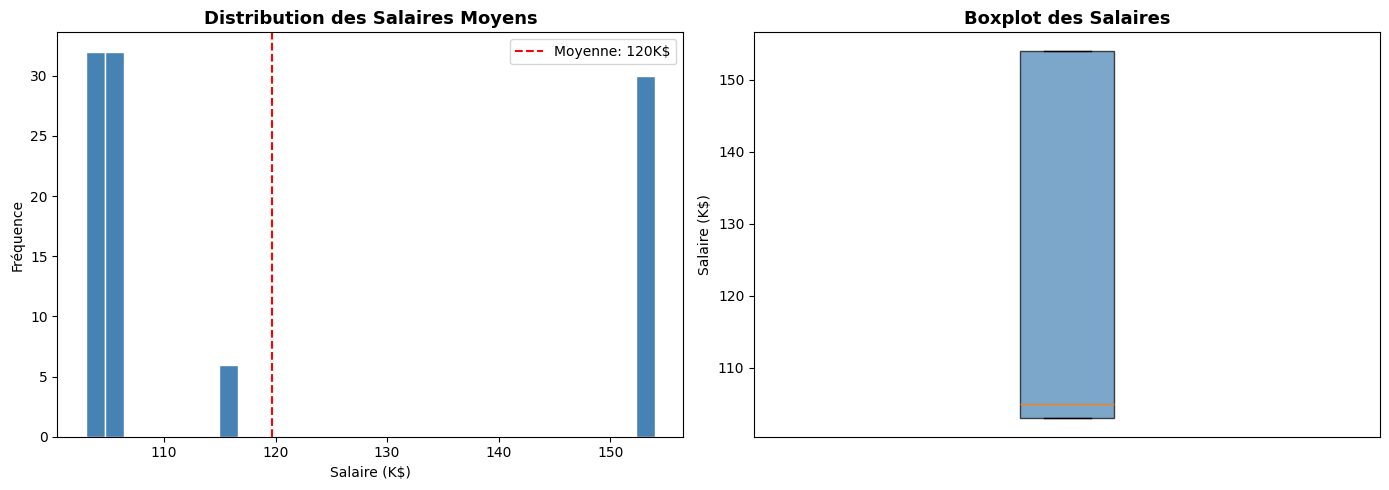

Salaire moyen  : $119,690
Salaire médian : $105,000
Min : $103,000 | Max : $154,000


In [23]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogramme
axes[0].hist(df_clean['salary_avg'] / 1000, bins=30, color='steelblue', edgecolor='white')
axes[0].set_title('Distribution des Salaires Moyens', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Salaire (K$)')
axes[0].set_ylabel('Fréquence')
axes[0].axvline(df_clean['salary_avg'].mean() / 1000, color='red', linestyle='--', label=f'Moyenne: {df_clean["salary_avg"].mean()/1000:.0f}K$')
axes[0].legend()

# Boxplot
axes[1].boxplot(df_clean['salary_avg'] / 1000, patch_artist=True,
                boxprops=dict(facecolor='steelblue', alpha=0.7))
axes[1].set_title('Boxplot des Salaires', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Salaire (K$)')
axes[1].set_xticks([])

plt.tight_layout()
plt.savefig('plot_salary_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Salaire moyen  : ${df_clean["salary_avg"].mean():,.0f}')
print(f'Salaire médian : ${df_clean["salary_avg"].median():,.0f}')
print(f'Min : ${df_clean["salary_avg"].min():,.0f} | Max : ${df_clean["salary_avg"].max():,.0f}')

In [24]:
# df = df.drop(columns=["Founded","Job Title","Salary Estimate"])
df.columns

Index(['index', 'Job Title', 'Salary Estimate', 'Job Description', 'Rating',
       'Company Name', 'Location', 'Headquarters', 'Size', 'Founded',
       'Type of ownership', 'Industry', 'Sector', 'Revenue', 'Competitors',
       'extracted_skills', 'salary_avg', 'company_clean', 'job_title_clean'],
      dtype='str')

In [25]:
# ── Encoders globaux (réutilisés à la prédiction) ───────────────────────
le_sector  = LabelEncoder()
le_state   = LabelEncoder()
le_owner   = LabelEncoder()
le_revenue = LabelEncoder()

def build_features(df, fit=True):
    """
    Feature engineering enrichi — utilise TOUTES les colonnes disponibles.
    fit=True lors de l'entraînement, fit=False lors de la prédiction.
    """
    d = df.copy()

    # ── 1. Features sur le titre ────────────────────────────────────────────
    title = d['job_title_clean'].fillna('').str.lower()
    d['is_senior']   = title.str.contains(r'senior|sr\.?\b|lead|principal|staff', regex=True).astype(int)
    d['is_junior']   = title.str.contains(r'junior|jr\.?\b|entry|associate', regex=True).astype(int)
    d['is_data']     = title.str.contains(r'data|analytics|analyst', regex=True).astype(int)
    d['is_ml']       = title.str.contains(r'machine.?learning|\bml\b|\bai\b|deep.?learning|nlp', regex=True).astype(int)
    d['is_engineer'] = title.str.contains(r'engineer|developer|\bdev\b', regex=True).astype(int)
    d['is_manager']  = title.str.contains(r'manager|director|\bhead\b|\bvp\b|chief', regex=True).astype(int)
    d['is_research'] = title.str.contains(r'research|scientist', regex=True).astype(int)
    d['title_len']   = title.str.len()
    founded = pd.to_numeric(d['Founded'], errors='coerce')
    founded = founded.where(founded > 0)  # -1 → NaN
    d['company_age'] = (2024 - founded).fillna(25)
    d['sector_enc'] = le_sector.fit_transform(d['Sector'].fillna('Unknown'))
    d['state_enc'] = le_state.fit_transform(d['Location'].fillna('Unknown'))
    d['Rating'] = d['Rating'].fillna(d['Rating'].median())
    return d


df_feat = build_features(df_clean, fit=True)

# ── Features Skills (depuis extracted_skills) ───────────────────────────
import ast
from collections import Counter

def parse_skills(s):
    try:
        return [x.strip().lower() for x in ast.literal_eval(str(s)) if x.strip()]
    except:
        return [x.strip().lower() for x in str(s).split(',') if x.strip()]
df_feat['extracted_skills'] = df_clean['extracted_skills'].values
df_feat['skills_list'] = df_feat['extracted_skills'].apply(parse_skills)

# Top 15 skills les plus fréquentes
all_skills_flat = [s for skills in df_feat['skills_list'] for s in skills]
top_skills = pd.Series(Counter(all_skills_flat)).sort_values(ascending=False).head(15)
TOP_SKILLS = top_skills.index.tolist()

print('Top 15 skills les plus demandées :')
print(top_skills.to_string())

# Créer une feature binaire pour chaque top skill
SKILL_FEATURES = []
for skill in TOP_SKILLS:
    col = 'skill_' + skill.replace(' ', '_').replace('-', '_')[:20]
    df_feat[col] = df_feat['skills_list'].apply(
        lambda s: int(any(skill in x for x in s))
    )
    SKILL_FEATURES.append(col)

# Feature : nombre total de skills extraites
df_feat['skill_count'] = df_feat['skills_list'].apply(len)
SKILL_FEATURES.append('skill_count')

print(f'\nFeatures skills créées : {SKILL_FEATURES}')

# ── FEATURES COMPLÈTES ──────────────────────────────────────────────────
FEATURES = [
    # Titre
    'is_senior', 'is_junior', 'is_data', 'is_ml', 'is_engineer',
    'is_manager', 'is_research', 'title_len',
    'Rating', 'company_age', 'sector_enc',
    'state_enc'

] + SKILL_FEATURES  # ← skills NER ajoutées !

print(f'\nTotal features : {len(FEATURES)} ({len(SKILL_FEATURES)} skills + {len(FEATURES)-len(SKILL_FEATURES)} autres)')
print(f'Samples        : {len(df_feat)}')



Top 15 skills les plus demandées :
data                50
machine learning    29
business            26
data science        25
support             19
research            19
analyze             17
develop             13
insights            13
technology          12
development         11
collaborate         10
analysis            10
analytics           10
design               9

Features skills créées : ['skill_data', 'skill_machine_learning', 'skill_business', 'skill_data_science', 'skill_support', 'skill_research', 'skill_analyze', 'skill_develop', 'skill_insights', 'skill_technology', 'skill_development', 'skill_collaborate', 'skill_analysis', 'skill_analytics', 'skill_design', 'skill_count']

Total features : 28 (16 skills + 12 autres)
Samples        : 100


In [26]:
print(FEATURES)
print({len(FEATURES)})

['is_senior', 'is_junior', 'is_data', 'is_ml', 'is_engineer', 'is_manager', 'is_research', 'title_len', 'Rating', 'company_age', 'sector_enc', 'state_enc', 'skill_data', 'skill_machine_learning', 'skill_business', 'skill_data_science', 'skill_support', 'skill_research', 'skill_analyze', 'skill_develop', 'skill_insights', 'skill_technology', 'skill_development', 'skill_collaborate', 'skill_analysis', 'skill_analytics', 'skill_design', 'skill_count']
{28}


In [27]:
X = df_feat[FEATURES]
y = df_feat['salary_avg']

In [28]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [29]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(
    n_estimators=300,
    max_depth=12,
    random_state=42
)

model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",12
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples 

In [30]:
from sklearn.metrics import r2_score, mean_squared_error

y_pred = model.predict(X_test)

r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

print("R2 score :", r2)
print("MSE      :", mse)
print("RMSE     :", rmse)

R2 score : -0.08242557617251944
MSE      : 558787996.8633759
RMSE     : 23638.69702126951


In [31]:
# import joblib

# joblib.dump(model, "../models/salary_model.pkl")

In [40]:
import joblib
from pathlib import Path

from sklearn.model_selection import cross_val_score

Path("../ml/models").mkdir(parents=True, exist_ok=True)

model_payload = {
    'regressor':      model,
    'model_name':     'Random Forest',
    'features':       FEATURES,
    'top_skills':     TOP_SKILLS,
    'skill_features': SKILL_FEATURES,
    'le_sector':      le_sector,
    'le_state':       le_state,
    'metrics': {
        'r2':         float(r2),
        'rmse':       float(rmse),
        'mse' :       float(mse)
    }
}

joblib.dump(model_payload, '../ml/models/salary_model.pkl')

# Vérification
loaded = joblib.load('../ml/models/salary_model.pkl')
print(f'Type    : {type(loaded)}')
print(f'Clés    : {list(loaded.keys())}')
print(f'Features: {len(loaded["features"])} features')
print(f'R²      : {loaded["metrics"]["r2"]:.4f}')
print(f'RMSE    : {loaded["metrics"]["rmse"]:.2f}')
print(f'MSE     : {loaded["metrics"]["mse"]:.4f}')


Type    : <class 'dict'>
Clés    : ['regressor', 'model_name', 'features', 'top_skills', 'skill_features', 'le_sector', 'le_state', 'metrics']
Features: 28 features
R²      : -0.0824
RMSE    : 23638.70
MSE     : 558787996.8634


In [ ]:
# model = joblib.load("../models/salary_model.pkl")
# print(type(model))  # doit être <class 'dict'>

<class 'sklearn.ensemble._forest.RandomForestRegressor'>
